# Esercizi

## 1. La legge dei grandi numeri

### La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

### Vale a dire, la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.

### - Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
### - Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
### - Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)

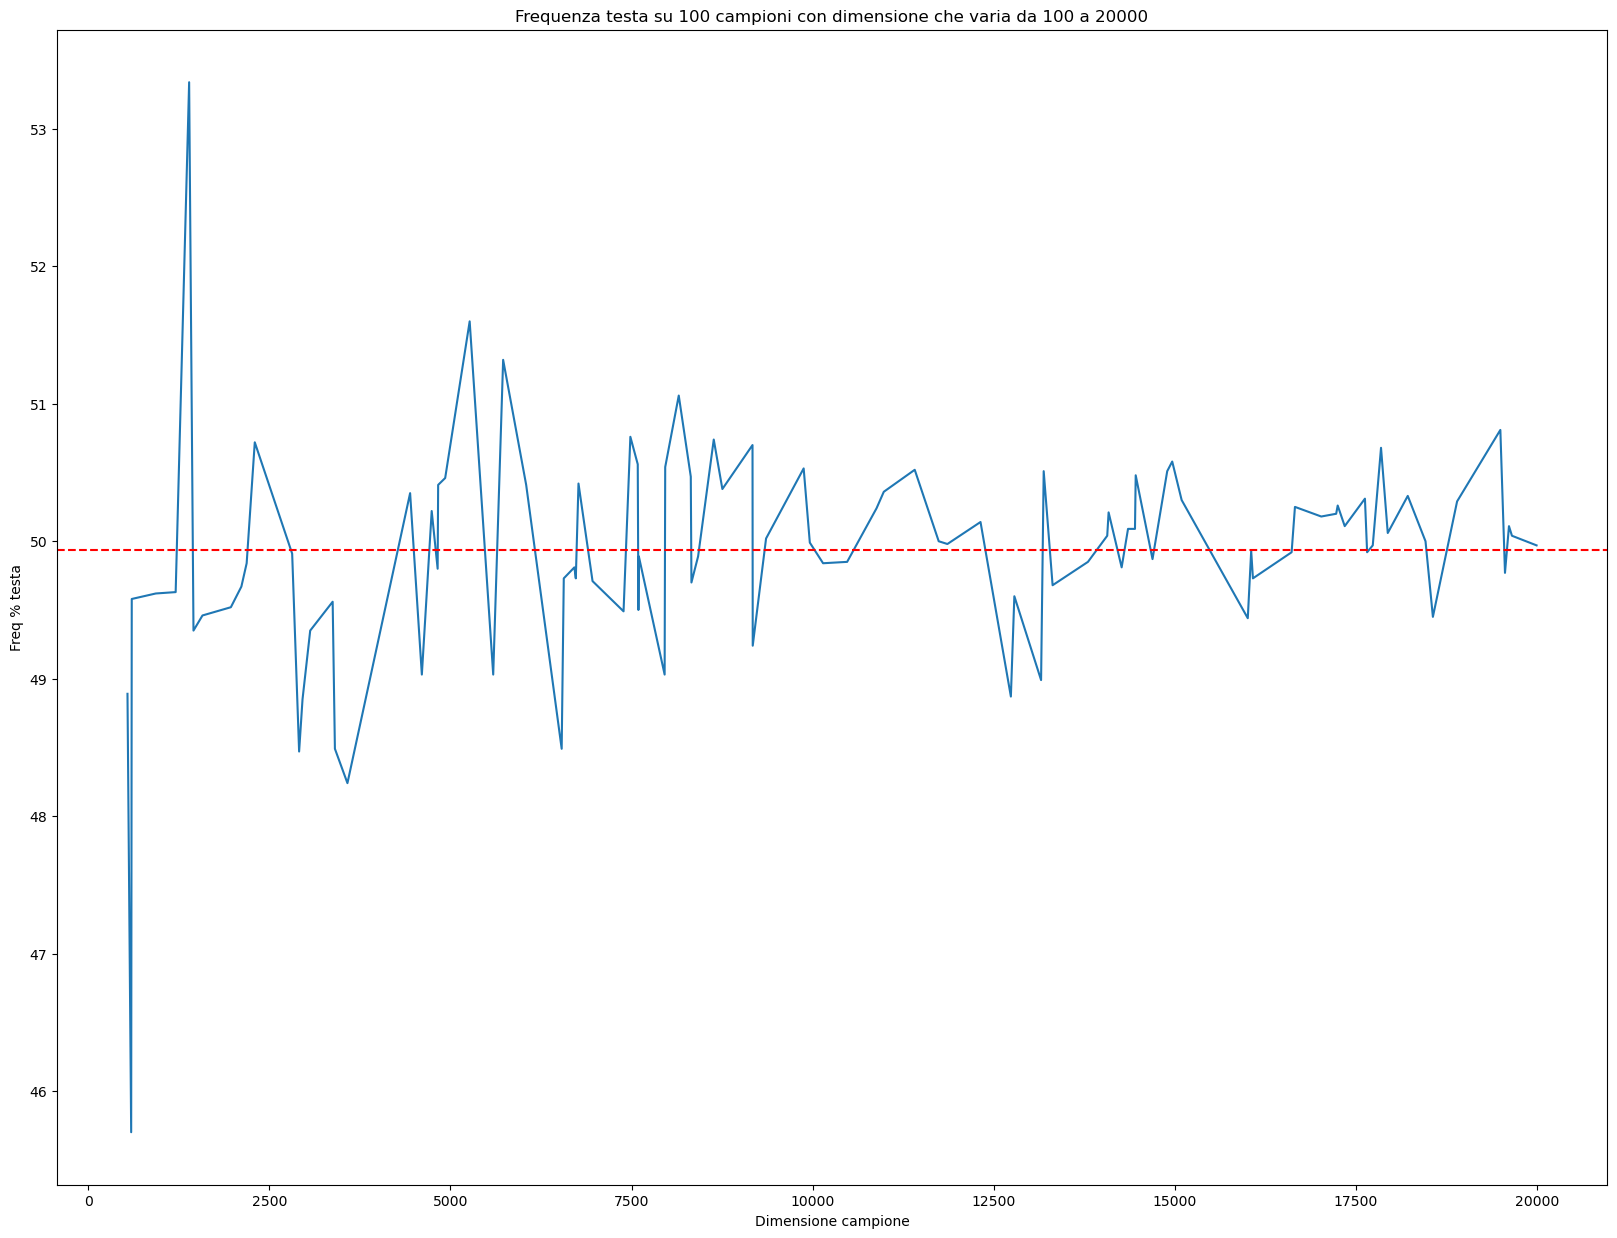

In [211]:
# lancio moneta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def lancio_moneta(n):
    
    lanci = np.random.randint(0, 2, n)
    return round(np.sum(lanci)/n*100, 2)
    
res_fin = []
campioni = []    
    
for i in range(0, 100):
    n = np.random.randint(10, 20001)
    res = lancio_moneta(n)
    #print(f"Freq. % testa al turno {i+1} con {n} lanci: {res}%")
    res_fin.append(res)
    campioni.append(n)

df = pd.DataFrame([[campioni[i], res_fin[i]] for i in range(len(campioni))])
df = df.sort_values(by=0, ascending=True)

plt.figure(figsize=(20,15))

plt.plot(df[0], df[1])
plt.xlabel("Dimensione campione")
plt.ylabel("Freq % testa")
plt.title("Frequenza testa su 100 campioni con dimensione che varia da 100 a 20000")
plt.axhline(df[1].mean(), color="red", linestyle="--")

plt.show()



## 2. Analisi del Dataset Titanic 

### - Quante righe e colonne ha il dataset?
### - Controlla quanti valori mancanti ci sono per colonna
### - Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
### - Controlla se ci sono righe duplicate
### - Calcola l'età media dei passeggeri per ogni classe (Pclass), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
### - Visualizza la distribuzione dell'età per classe
### - Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [212]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [213]:
print(f"N. Righe data frame: {df.shape[0]}, N. Colonne data frame: {df.shape[1]}")

N. Righe data frame: 891, N. Colonne data frame: 12


In [214]:
#conto gli na per ogni colonna

df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [215]:
# Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente

print(df[df["Embarked"].isna()])

df.loc[df["Embarked"].isna(), "Embarked"] = df["Embarked"].mode()[0]

print(df[df["Embarked"].isna()])


     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  
61   female  38.0      0      0  113572  80.0   B28      NaN  
829  female  62.0      0      0  113572  80.0   B28      NaN  
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


In [216]:
# Controlla se ci sono righe duplicate

any(df.duplicated())

False

In [217]:
# Calcola l'età media dei passeggeri per ogni classe (Pclass),
#se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio


df.loc[df["Age"].isna(), "Age"] = round(df["Age"].mean(), 0)
df.groupby("Pclass")["Age"].mean()



Pclass
1    37.089907
2    29.884946
3    26.486599
Name: Age, dtype: float64

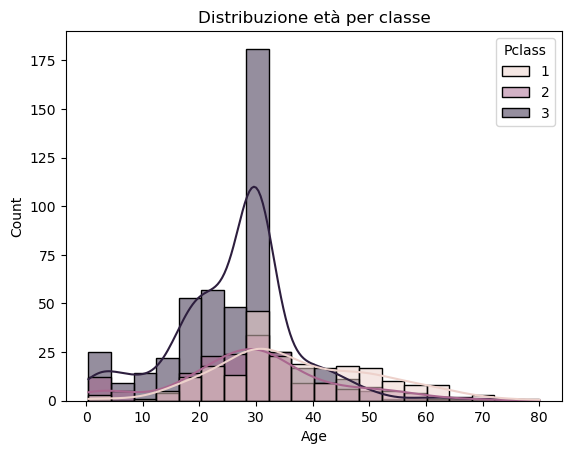

In [218]:
# Visualizza la distribuzione dell'età per classe

sns.histplot(data=df, x="Age", kde=True, hue="Pclass", bins=20, alpha=0.5)
plt.title("Distribuzione età per classe")
plt.show()

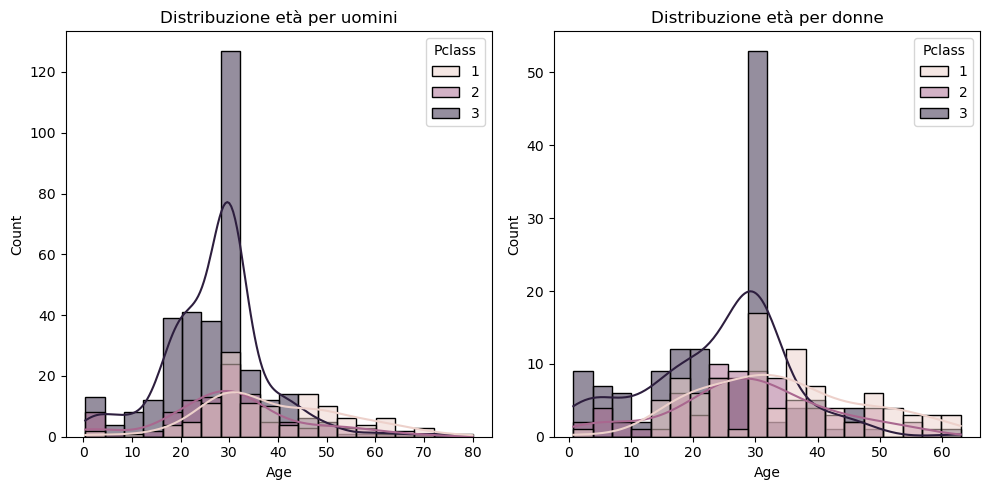

In [219]:
# Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

m = df[df["Sex"] == "male"]
f = df[df["Sex"] == "female"]



fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(data=m, x="Age", kde=True, hue="Pclass", bins=20, alpha=0.5, ax=ax[0])
ax[0].set_title("Distribuzione età per uomini")

sns.histplot(data=f, x="Age", kde=True, hue="Pclass", bins=20, alpha=0.5, ax=ax[1])
ax[1].set_title("Distribuzione età per donne")


plt.tight_layout()
plt.show()


## 3. Analisi del Dataset Iris

### - Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
### - Calcola la lunghezza e la larghezza media dei petali per specie
### - Visualizza le dimensioni dei petali per specie (scatterplot)
### - Crea una nuova colonna per l'area del petalo e analizzala
### - Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [220]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [221]:
# esplorazione distribuzione per specie

df.groupby("species")["species"].count()

species
setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [222]:
# Calcola la lunghezza e la larghezza media dei petali per specie

df.groupby("species")[["petal_length", "petal_width"]].mean()

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


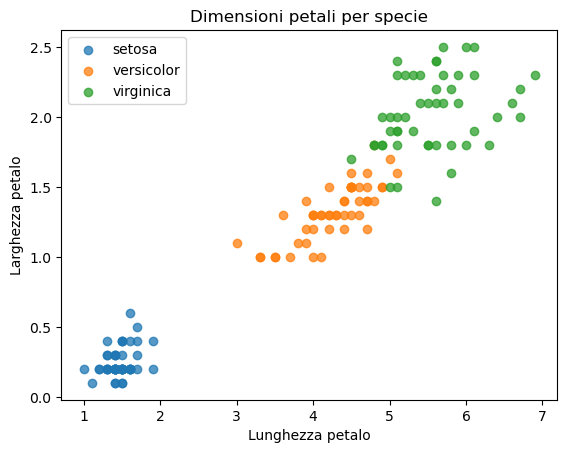

In [223]:
# Visualizza le dimensioni dei petali per specie (scatterplot)



for species, group in df.groupby("species"):
    plt.scatter(group["petal_length"], group["petal_width"], label=species, alpha=0.75)

plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.title("Dimensioni petali per specie")
plt.legend()
plt.show()





In [226]:
# Crea una nuova colonna per l'area del petalo e analizzala

df["petal_area"] = df["petal_length"] * df["petal_width"]

df.groupby("species")["petal_area"].describe()



,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,0.3656,0.181155,0.11,0.2800,0.300,0.42,0.96
versicolor,50.0,5.7204,1.368403,3.30,4.8600,5.615,6.75,8.64
virginica,50.0,11.2962,2.157412,7.50,9.7175,11.445,12.79,15.87


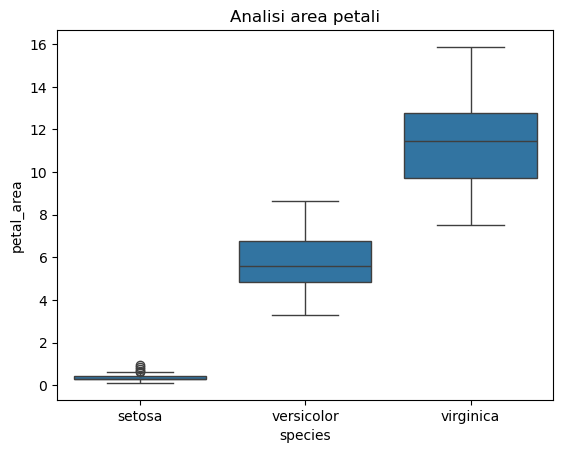

In [225]:
# Grafico della distribuzione dell'area del petalo per specie (boxplot)

sns.boxplot(data=df, x="species", y="petal_area")
plt.title("Analisi area petali")
plt.show()